In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.preprocessing import StandardScaler
import os
import globals as gl
from Pcm import find_model
import PcmPy as pcm
import pickle
from scipy.stats import ttest_1samp, pearsonr
from matplotlib.patches import ConnectionPatch, Rectangle
from matplotlib import colormaps as cm
from Plot import add_significant_patches_to_ml_rois, add_lineplot_to_boxplot, set_spines_and_ticks_width, add_noise_ceiling, save_figure_incremental

plt.style.use('default')

0 - model fit SMA: 0.2168015590022405
1 - model fit PMd: 0.40192802145742074
2 - model fit PMv: 0.10324578788437737
3 - model fit M1: 0.3793516295092825
4 - model fit S1: 0.48536127577525434
5 - model fit SPLa: 0.31129973053193055
6 - model fit SPLp: 0.26630566561933916
7 - model fit V1: 0.6137755785558082


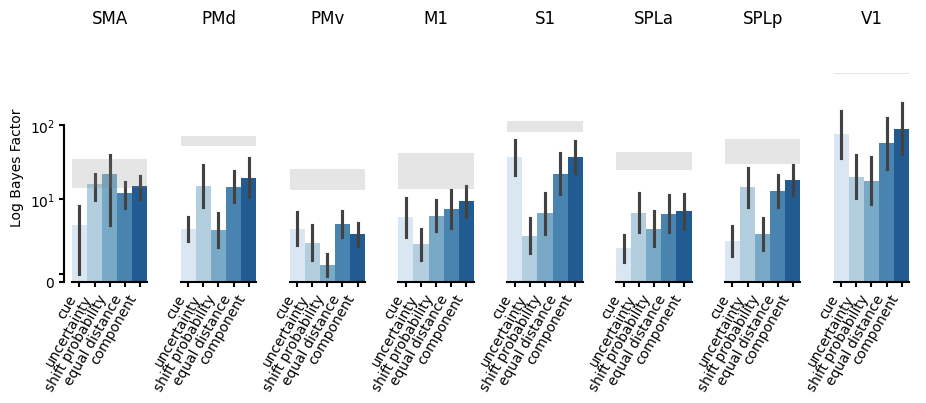

In [9]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

Mc, idxc = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.pkl'), 'component')

vmin, vmax = -.1, 1

fig, axs = plt.subplots(1, len(rois), figsize=(11, 3), sharex=True, sharey=True)

LL = pd.DataFrame()
for r, roi in enumerate(rois):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{Hem}.{roi}.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.plan.glm{glm}.{Hem}.{roi}.pkl'))

    # Subtract the baseline
    baseline = T_cv.likelihood.loc[:,'null'].values
    likelihood = T_cv.likelihood - baseline.reshape(-1,1)

    plt.sca(axs[r])
    ax = pcm.model_plot(T_cv.likelihood,
                    null_model = 'null',
                    noise_ceiling= 'ceil',
                    upper_ceiling = T_gr.likelihood['ceil'],
                    width=1,
                    palette='Blues',
                    errorbar='se')
    ax.set_title(roi, pad=20)
    ax.set_xlabel('')
    ax.set_yscale('symlog', linscale=.1, linthresh=1)
    ax.spines[['bottom',]].set_bounds(-.5, 4.5)
    ax.spines[['left',]].set_bounds(0, 10**2)
    ax.set_ylim(0, 10**3 - 0.0001)
    ax.set_yticks([0, 10, 100])
    ax.set_xlim(-1, 5)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{Hem}.{roi}.npy'))
    D_obs = pcm.G_to_dist(G_obs.mean(axis=0) / np.trace(G_obs.mean(axis=0)))

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.plan.glm{glm}.{Hem}.{roi}.pkl'), "rb")
    theta = pickle.load(f)
    theta_c = theta[idxc][:Mc.n_param]

    G_hat_c = []
    for i in range(theta_c.shape[1]):
        G_hat_c_tmp, _ = Mc.predict(theta_c[:, i])
        G_hat_c.append(G_hat_c_tmp)

    G_hat_c = np.array(G_hat_c)

    correlations = []
    for i in range(G_hat_c.shape[0]):
        # Average G_hat across all folds except i
        G_hat_mean = np.mean(np.delete(G_hat_c, i, axis=0), axis=0)

        # Vectorize upper triangle (excluding diagonal)
        mask = np.triu_indices_from(G_obs[i], k=1)
        vec_obs = G_obs[i][mask]
        vec_hat = G_hat_mean[mask]

        # Compute correlation using np.corrcoef
        corr = np.corrcoef(vec_obs, vec_hat)[0, 1]
        correlations.append(corr)

    correlations = np.array(correlations).mean()

    print(f"{r} - model fit {roi}: {correlations}")

    insetx = .05
    insety = (1.08, 1.42)
    insetw = .8
    inseth = .25
    cbarc = (insety[0] + insety[1] + inseth) / 2
    cbarx = .9
    cbarw = 0.4

#     # Create first inset (upper)
#     inset1 = ax.inset_axes([insetx, insety[1], insetw, inseth], transform=ax.transAxes)  # [x0, y0, width, height]
#     cax = inset1.imshow(D_obs, vmin=vmin, vmax=vmax)  # Replace with your plotting code for the first inset
#     inset1.set_xticks([])
#     inset1.set_yticks([])
#     inset1.set_title('Observed', fontsize=8, pad=3)
#     if r==0:
#         inset1.set_yticks(np.arange(5))
#         inset1.set_yticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8)


    # Create second inset (just below the first)
    # inset2 = ax.inset_axes([insetx, insety[0], insetw, inseth], transform=ax.transAxes)
    # # inset2.imshow(np.array(Dc).mean(axis=0), vmin=vmin, vmax=vmax)
    # inset2.set_title('Predicted', fontsize=8, pad=3)
    # inset2.set_xticks(np.arange(5))
    # inset2.set_xticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8, rotation=60, ha='right')
    # inset2.set_yticks([])
    # if r==0:
    #     inset2.set_yticks(np.arange(5))
    #     inset2.set_yticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8,)
    #
    # # Add colorbar
    # if r == len(rois) - 1:
    #     cbar_ax = ax.inset_axes([cbarx, cbarc-cbarw/2, 0.05, cbarw], transform=ax.transAxes)  # [left, bottom, width, height] in figure coordinates
    #     cbar = fig.colorbar(cax, cax=cbar_ax)
    #     cbar.ax.tick_params(labelsize=8)
    #     cbar.set_label('Squared crossnobis distance (a.u.)', fontsize=8)

    if r == 0:
        ax.spines[['top', 'right',]].set_visible(False)
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        ax.spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(ax, tick_width=0, axes='y')
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

# fig.tight_layout()
# save_figure_incremental(fig, 'ml_neural_plan')
plt.show()

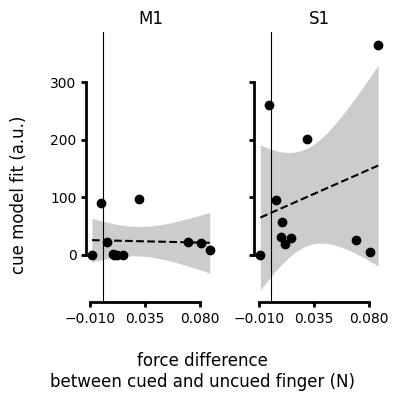

In [10]:
from scipy.stats import linregress, t

rois = ['M1', 'S1', ]
Hem = 'L'
snS = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112]
experiment = 'smp2'
glm = 12

df = pd.DataFrame()
diff1, diff2, diff3 = np.zeros(len(snS)), np.zeros(len(snS)), np.zeros(len(snS))
for s, sn in enumerate(snS):
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}.dat'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df, df_tmp])
    diff1[s] = (df[df['cue'] == 39]['index0'].mean() - df[df['cue'] == 93]['index0'].mean() +
                df[df['cue'] == 93]['ring0'].mean() - df[df['cue'] == 39]['ring0'].mean()) / 2
    diff3[s] = (df[df['stimFinger'] == 91999]['index1'].mean() - df[df['stimFinger'] == 99919]['index1'].mean() +
                df[df['stimFinger'] == 99919]['ring1'].mean() - df[df['stimFinger'] == 91999]['ring1'].mean()) / 2
    diff2[s] = dat['forceDiff'].mean()

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(4, 4))

for r, roi in enumerate(rois):

    LL_cue = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{Hem}.{roi}.pkl'))['likelihood']['cue'] - pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{Hem}.{roi}.pkl'))['likelihood']['null']

    # Regression for diff2
    x = diff2
    y = LL_cue
    slope, intercept, r_value, p_value, std_err = linregress(x, y)

    x_fit = np.linspace(np.min(x), np.max(x), 100)
    y_fit = slope * x_fit + intercept

    # Compute confidence intervals
    n = len(x)
    y_pred = slope * x + intercept
    residuals = y - y_pred
    dof = n - 2
    t_val = t.ppf(0.975, dof)

    se_line = np.sqrt(
        np.sum(residuals**2) / dof * (1/n + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
    )
    ci = t_val * se_line

    axs[r].plot(x_fit, y_fit, color='k', linestyle='--', label='Fit')
    axs[r].fill_between(x_fit, y_fit - ci, y_fit + ci, color='k', alpha=.2, label='95% CI', lw=0)
    axs[r].scatter(x, y, color='k')

    axs[r].axvline(0, lw=.8, color='k')

    axs[r].set_title(roi)

    # Remove spines from 'left', 'top', and 'right'
    axs[r].spines['left'].set_bounds(0, 300)
    axs[r].spines['bottom'].set_bounds(-.01, .08)
    axs[r].spines['top'].set_visible(False)
    axs[r].spines['right'].set_visible(False)

    # Set ticks for x-axis and y-axis
    axs[r].set_xticks(np.linspace(-.01, .08, 3))
    axs[r].tick_params(width=2)

    # Set linewidth for remaining spines ('bottom') and ticks
    axs[r].spines['bottom'].set_linewidth(2)
    axs[r].spines['left'].set_linewidth(2)

fig.supxlabel('force difference\nbetween cued and uncued finger (N)')
fig.supylabel('cue model fit (a.u.)')

fig.tight_layout()


0 - model fit SMA: -0.014244794411365386
1 - model fit PMd: 0.09731878048894993
2 - model fit PMv: 0.07219994900810557
3 - model fit M1: 0.5083543901524961
4 - model fit S1: 0.6490387284961127
5 - model fit SPLa: 0.07545401961080665
6 - model fit SPLp: 0.05004687684447227
7 - model fit V1: -0.007220399298215514


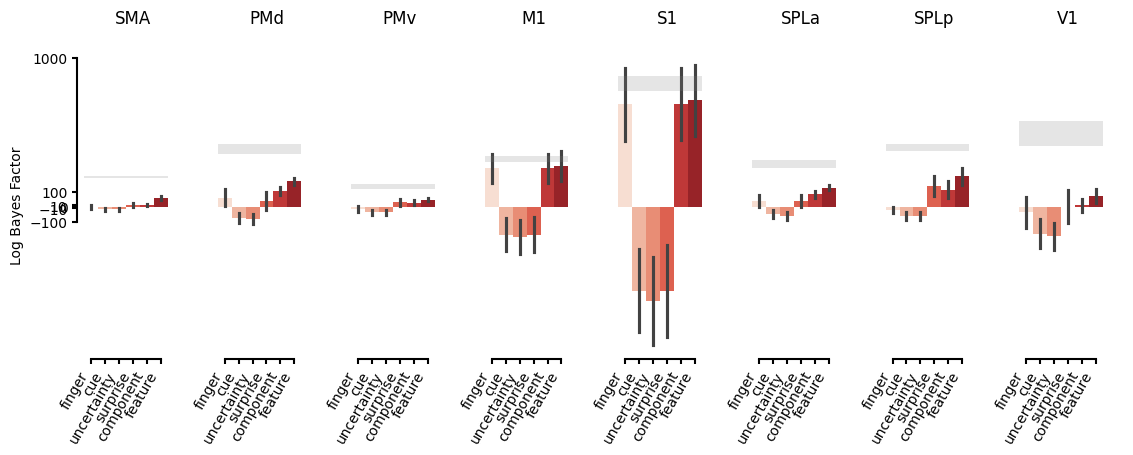

In [11]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

Mf, idxf = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.pkl'), 'feature')

fig, axs = plt.subplots(1, len(rois), figsize=(13.5, 4), sharex=True, sharey=True)

colors = sns.color_palette("Reds", n_colors=5)

LL = pd.DataFrame()
for r, roi in enumerate(rois):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.exec.glm{glm}.{Hem}.{roi}.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.exec.glm{glm}.{Hem}.{roi}.pkl'))

    # Subtract the baseline
    baseline = T_cv.likelihood.loc[:,'null'].values
    likelihood = T_cv.likelihood - baseline.reshape(-1,1)

    plt.sca(axs[r])
    ax = pcm.model_plot(T_cv.likelihood,
                    null_model = 'null',
                    noise_ceiling= 'ceil',
                    upper_ceiling = T_gr.likelihood['ceil'],
                    width=1,
                    palette='Reds',
                    errorbar='se',)
    ax.set_title(roi, pad=20)
    ax.set_xlabel('')
    # ax.set_yscale('symlog')
    ax.spines[['bottom',]].set_bounds(0, 5)
    ax.spines[['left',]].set_bounds(-10**2, 10**3)
    ax.set_yticks([ -100, -10, 0, 10, 100, 1000])
    ax.set_xlim(-1, 7)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{Hem}.{roi}.npy'))
    D_obs = pcm.G_to_dist(G_obs.mean(axis=0) / np.trace(G_obs.mean(axis=0)))

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.exec.glm{glm}.{Hem}.{roi}.pkl'), "rb")
    theta = pickle.load(f)
    theta_f = theta[idxf][:Mf.n_param]

    G_hat = []
    for i in range(theta_f.shape[1]):
        G_hat_tmp, _ = Mf.predict(theta_f[:, i])
        G_hat.append(G_hat_tmp)

    G_hat = np.array(G_hat)

    correlations = []
    for i in range(G_hat.shape[0]):
        # Average G_hat across all folds except i
        G_hat_mean = np.mean(np.delete(G_hat, i, axis=0), axis=0)

        G_hat_mean /= np.trace(G_hat_mean)
        G_obs[i] /= np.trace(G_obs[i])

        # Vectorize upper triangle (excluding diagonal)
        mask = np.triu_indices_from(G_obs[i], k=1)
        vec_obs = G_obs[i][mask]
        vec_hat = G_hat_mean[mask]

        # Compute correlation using np.corrcoef
        corr = np.corrcoef(vec_obs, vec_hat)[0, 1]
        correlations.append(corr)

    correlations = np.array(correlations).mean()

    print(f"{r} - model fit {roi}: {correlations}")

    if r == 0:
        ax.spines[['top', 'right',]].set_visible(False)
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        ax.spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(ax, tick_width=0, axes='y')
        set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

plt.show()

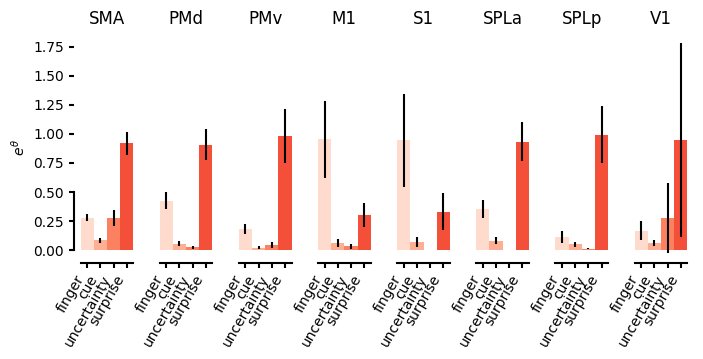

In [12]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.pkl'), 'component')
n_param = M.n_param
components = ['finger', 'cue','uncertainty', 'surprise']

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(8, 3),)

colors = sns.color_palette("Reds", n_colors=6)[:4]

for r, roi in enumerate(rois):

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{Hem}.{roi}.pkl'), "rb")
    theta = np.exp(pickle.load(f)[idx][:n_param])

    theta_avg = theta.mean(axis=1)
    theta_err = theta.std(axis=1) / np.sqrt(theta.shape[1])

    axs[r].bar(components, theta_avg / np.linalg.norm(theta_avg), width=1, facecolor=colors, yerr=theta_err,)
    axs[r].set_xticks(axs[r].get_xticks())
    axs[r].set_xticklabels(axs[r].get_xticklabels(), rotation=60, ha='right')

    axs[r].set_title(roi)

    axs[r].spines[['bottom',]].set_bounds(-.5, 3.5)
    axs[r].spines[['left',]].set_bounds(0, .5)
    axs[r].set_xlim(-1, 4)

    if r == 0:
        axs[r].set_ylabel(r'$e^{\theta}$')
        axs[r].spines[['top', 'right',]].set_visible(False)
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('left', 'bottom',), tick_width=1.5,axes=('x', 'y'),which='both')
    else:
        axs[r].spines[['top', 'right','left']].set_visible(False)
        set_spines_and_ticks_width(axs[r], tick_width=0, axes='y')
        set_spines_and_ticks_width(axs[r], spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

plt.show()

SMA: -17.775783304558164
PMd: -10.06291585456291
PMv: 0.6356969983152561
M1: 59.55033114312845
S1: 1.08936363666458
SPLa: -6.208195619516033
SPLp: -57.46550900039279
V1: 0.8442543438081965
Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/feat_model_coeff_neural_plan.svg


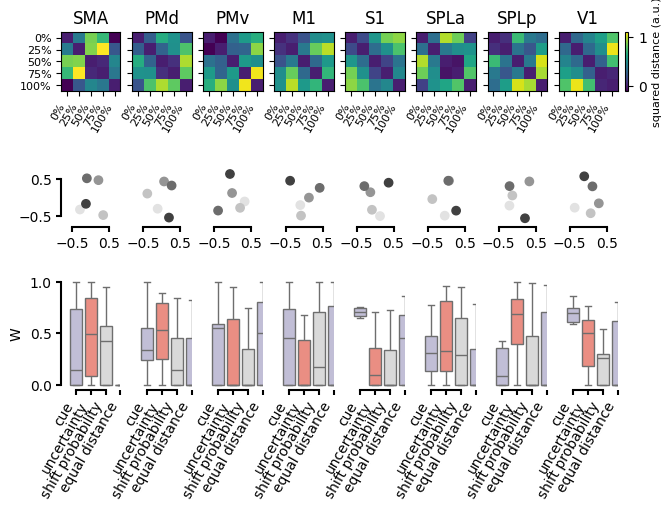

In [13]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

features = np.array(['cue', 'uncertainty', 'shift probability','equal distance'])
x_pos = [0, 1.5, 2.5, 4, 5.5, 7]

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.pkl'), 'component')
n_param = Mf.n_param

vmin, vmax = -.1, 1.1

colors = sns.color_palette("Set3", n_colors=9) #+ [(.5, .5, .5)]
colors = [colors[2], colors[3], colors[8]]  # match color used for execution

fig, axs = plt.subplots(3, len(rois), figsize=(7, 5), sharey='row')

for r, roi in enumerate(rois):

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{Hem}.{roi}.pkl'))

    baseline = T_cv.likelihood.loc[:,'null'].values
    likelihood = T_cv.likelihood - baseline.reshape(-1,1)

    print(f"{roi}: {(likelihood['component'] / likelihood['ceil']).mean()}")
    # fit_err = (likelihood['component'] / likelihood['ceil']).std() / np.sqrt(likelihood['component'].shape[0])

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.plan.glm{glm}.{H}.{roi}.npy')).mean(axis=0)
    D_obs = pcm.G_to_dist(G_obs / np.trace(G_obs))

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.plan.glm{glm}.{H}.{roi}.pkl'), "rb")

    # Top row: imshow
    im_ax = axs[0, r]
    cax = im_ax.imshow(D_obs, vmin=vmin, vmax=vmax)
    im_ax.set_xticks(np.arange(5))
    im_ax.set_xticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8, rotation=60, ha='right')
    im_ax.set_title(roi)
    if r==0:
        im_ax.set_yticks(np.arange(5))
        im_ax.set_yticklabels(list(gl.regressor_mapping.keys())[:5], fontsize=8)

    # Middle row: MDS
    scatter_ax = axs[1, r]
    W, _ = pcm.classical_mds(G_obs/ np.trace(G_obs))
    scatter_ax.scatter(W[:, 1], W[:, 0], c=list(gl.colour_mapping.values())[:5])
    scatter_ax.set_xlim(-.8, .8)
    scatter_ax.set_ylim(scatter_ax.get_xlim())
    scatter_ax.set_xticks([-.5, .5])
    scatter_ax.set_yticks([-.5, .5])
    scatter_ax.set_aspect('equal')
    scatter_ax.spines[['top', 'right']].set_visible(False)
    scatter_ax.spines[['bottom', 'left']].set_bounds(-.5, .5)
    set_spines_and_ticks_width(scatter_ax, spine_sides=('left', 'bottom'), tick_width=1.5)
    if r>0:
        scatter_ax.spines[['top', 'right', 'left']].set_visible(False)
        set_spines_and_ticks_width(scatter_ax, tick_width=0, axes='y')

    # Bottom row: bar plot
    row_ax = axs[2, r]
    params = pickle.load(f)[idx]
    theta = params[:n_param]
    theta_exp = np.exp(theta)
    theta_sqrt = np.sqrt(theta_exp)
    theta_scaled = theta_sqrt / np.linalg.norm(theta_sqrt, axis=0, keepdims=True)
    theta_avg = theta_scaled.mean(axis=1)
    theta_err = theta_scaled.std(axis=1) / np.sqrt(theta_scaled.shape[1])

    df = pd.DataFrame(theta_scaled.T, columns=features)

    # row_ax.bar(features, theta_avg, width=1, yerr=theta_err, color=colors)
    sns.boxplot(data=df, ax=row_ax, palette=colors, showfliers=False, width = .8)
    # row_ax.plot(theta_avg, color='k', lw=1.5)
    # row_ax.fill_between(features, theta_avg - theta_err, theta_avg + theta_err, color='k', lw=0, alpha=.2)
    row_ax.set_xticks(row_ax.get_xticks())
    row_ax.set_xticklabels(features, rotation=60, ha='right')
    # row_ax.axhline(0, color='k', lw=0.8)
    # row_ax.set_title(f'fit={fit:.2f}')
    row_ax.spines[['top', 'right']].set_visible(False)
    row_ax.set_xlim((-1, 3))
    row_ax.spines[['left',]].set_bounds(0, 1)
    row_ax.spines[['bottom',]].set_bounds(0, 2)
    set_spines_and_ticks_width(row_ax, spine_sides=('left', 'bottom'), tick_width=1.5)
    if r == 0:
        row_ax.set_ylabel('W')
    else:
        row_ax.spines[['top', 'right', 'left']].set_visible(False)
        set_spines_and_ticks_width(row_ax, tick_width=0, axes='y')

# Colorbar for imshow (top row)
fig.subplots_adjust(right=0.92)
bbox = axs[0, 0].get_position()
cbar_ax = fig.add_axes([0.93, bbox.y0, 0.005, bbox.y1 - bbox.y0])
fig.colorbar(cax, cax=cbar_ax).set_label('squared distance (a.u.)', fontsize=8)

save_figure_incremental(fig, 'feat_model_coeff_neural_plan')

plt.show()

Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/feat_model_coeff_neural_exec.svg


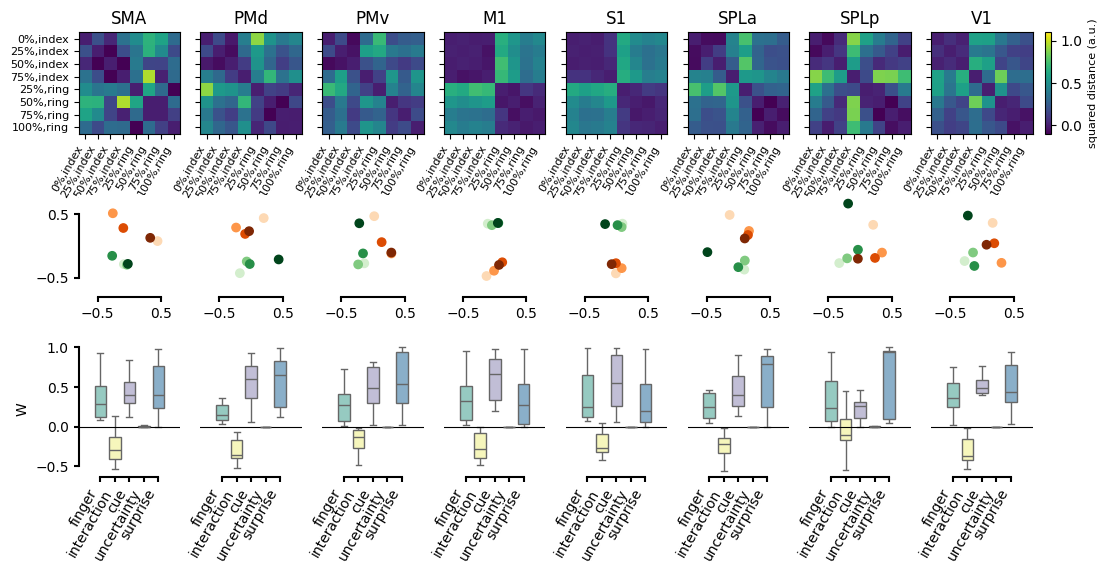

In [14]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
H = 'L'
experiment = 'smp2'

features = np.array(['finger', 'interaction', 'cue', 'uncertainty', 'surprise'])
x_pos = [0, 1.5, 2.5, 4, 5.5, 7]

Mf, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.exec.glm{glm}.pkl'), 'feature')

Ac = Mf.Ac.sum(axis=0)
n_param = Mf.n_param

vmin, vmax = -.1, 1.1

colors = sns.color_palette("Set3", n_colors=5) #+ [(.5, .5, .5)]
#colors = np.array(colors)[np.array([0, 4, 1, 2, 3])]

fig, axs = plt.subplots(3, len(rois), figsize=(12, 6), sharey='row')

for r, roi in enumerate(rois):

    G_obs = np.load(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'G_obs.exec.glm{glm}.{H}.{roi}.npy')).mean(axis=0)
    D_obs = pcm.G_to_dist(G_obs / np.trace(G_obs))

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_in.exec.glm{glm}.{H}.{roi}.pkl'), "rb")

    # Top row: imshow
    im_ax = axs[0, r]
    cax = im_ax.imshow(D_obs, vmin=vmin, vmax=vmax)
    im_ax.set_xticks(np.arange(8))
    im_ax.set_xticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8, rotation=60, ha='right')
    im_ax.set_title(roi)
    if r==0:
        im_ax.set_yticks(np.arange(8))
        im_ax.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], fontsize=8)

    # Middle row: MDS
    scatter_ax = axs[1, r]
    W, _ = pcm.classical_mds(G_obs/ np.trace(G_obs))
    scatter_ax.scatter(W[:, 1], W[:, 0], c=list(gl.colour_mapping.values())[5:13])
    scatter_ax.set_xlim(-.8, .8)
    scatter_ax.set_ylim(scatter_ax.get_xlim())
    scatter_ax.set_xticks([-.5, .5])
    scatter_ax.set_yticks([-.5, .5])
    scatter_ax.set_aspect('equal')
    scatter_ax.spines[['top', 'right']].set_visible(False)
    scatter_ax.spines[['bottom', 'left']].set_bounds(-.5, .5)
    set_spines_and_ticks_width(scatter_ax, spine_sides=('left', 'bottom'), tick_width=1.5)
    if r>0:
        scatter_ax.spines[['top', 'right', 'left']].set_visible(False)
        set_spines_and_ticks_width(scatter_ax, tick_width=0, axes='y')

    # Bottom row: bar plot
    row_ax = axs[2, r]
    params = pickle.load(f)[idx]
    theta = params[:n_param]
    theta_squared = theta**2
    theta_combined = np.vstack([theta_squared[0, :] + theta_squared[1, :], theta[1, :] * theta[2, :], theta_squared[2, :] + theta_squared[3, :],theta_squared[4:]])
    theta_scaled = theta_combined / np.linalg.norm(theta_combined, axis=0, keepdims=True)
    theta_avg = theta_scaled.mean(axis=1)
    theta_err = theta_scaled.std(axis=1) / np.sqrt(theta_scaled.shape[1])

    df = pd.DataFrame(theta_scaled.T, columns=features)

    # row_ax.bar(features, theta_avg, width=1, yerr=theta_err, color=colors)
    sns.boxplot(data=df, ax=row_ax, palette=colors, showfliers=False)
    # row_ax.plot(theta_avg, color='k', lw=1.5)
    # row_ax.fill_between(features, theta_avg - theta_err, theta_avg + theta_err, color='k', lw=0, alpha=.2)
    row_ax.set_xticks(row_ax.get_xticks())
    row_ax.set_xticklabels(features, rotation=60, ha='right')
    row_ax.axhline(0, color='k', lw=0.8)
    row_ax.spines[['top', 'right']].set_visible(False)
    row_ax.spines[['left',]].set_bounds(-.5, 1)
    row_ax.set_xlim((-1.5, 5.5))
    row_ax.spines[['bottom',]].set_bounds(0, 4)
    set_spines_and_ticks_width(row_ax, spine_sides=('left', 'bottom'), tick_width=1.5)
    if r == 0:
        row_ax.set_ylabel('W')
    else:
        row_ax.spines[['top', 'right', 'left']].set_visible(False)
        set_spines_and_ticks_width(row_ax, tick_width=0, axes='y')

# Colorbar for imshow (top row)
fig.subplots_adjust(right=0.92)
bbox = axs[0, 0].get_position()
cbar_ax = fig.add_axes([0.93, bbox.y0, 0.005, bbox.y1 - bbox.y0])
fig.colorbar(cax, cax=cbar_ax).set_label('squared distance (a.u.)', fontsize=8)

save_figure_incremental(fig, 'feat_model_coeff_neural_exec')

plt.show()